# HW 1

**Fall 2025 Quantiative Methods in Finance**

**The Erdös Institute**

1) Consider the process $X$ of randomly selecting numbers from the unit interval $[0,1]$ until the sum of values exceeds $1$. Prove that $E[X]=e$.

In [11]:
import numpy as np

num_expt = 100000 
final_counts = []
for _ in range(num_expt):
    S = 0
    count = 0
    while (S<=1):
        S += np.random.rand()
        count += 1
    final_counts.append(count)

n = np.array(final_counts)
print(f'The number of draws in each experiment is {n}.')
print(f'The mean number of draws is {np.mean(n)}.')

print(f'The probabilities that we need 2, 3, 4, and 5 draws are {float(np.mean(n == 2))}, {float(np.mean(n == 3))}, {float(np.mean(n == 4))} ,{float(np.mean(n == 5))} respectively.')


The number of draws in each experiment is [2 2 2 ... 2 2 2].
The mean number of draws is 2.71736.
The probabilities that we need 2, 3, 4, and 5 draws are 0.50164, 0.33075, 0.12586 ,0.03364 respectively.


We shall now solve the problem theoretically.


Let $m(x)$ be the average number of draws needed for the sum to exceed $x$. We want to show that $m(1) = e$. We know that $m(0) = 1$. Suppose our first draw is the number $u$. Then, we need to draw $x-u$ more in the remaining draws. Hence, averaging across all the possible initial draws gives
$$m(x) = 1 + \int_0^x m(x-u) du = 1 + \int_0^x m(z) dz ,$$
where the second equality follows from the variable substitution $z = x-u$. Differentiating both sides yields $m'(x) = m(x)$, whose solution is $m(x) = Ce^x$. Using the fact that $m(0) = 1$, we know that $C=1$. Therefore, $m(x) = e^x$ and $m(1) = e$.



Here's an alternate solution:

Let the numbers drawn be $\{x_1, x_2, \dots\}$. Suppose that their sum $S_k := \Sigma_{i=1}^k x_i$ exceeds $1$ on the $N^{\text{th}}$ draw. Thus,
$$S_N > 1, \quad S_{N-1} \le 1.$$

Now, it is easy to see that $N \neq 1$, since the first draw cannot exceed $1$ by itself. For any $N \ge 2$, assume that the first $N-1$ terms have been drawn already, so that $S_{N-1} \le 1$. Since the numbers are drawn from the uniform distribution on $[0,1]$, the probability that $x_N$ is large enough to make $S_N > 1$ can be calculated in the form of an integral of a conditional probability as
$$
\begin{equation*}
\begin{aligned}
    P(N) &= \underbrace{\int_0^1 \dots \int_0^1}_{(N-1) times} P(N\vert x_1, x_2, \dots, x_{N-1}) P(x_1, x_2, \dots, x_{N-1}) dx_1 \dots dx_{N-1} \\
    &= \underbrace{\int_0^1 \dots \int_0^1}_{(N-1) times} \left( \Sigma_{i=1}^{N-1} x_i \right) \Theta\left( \Sigma_{i=1}^{N-1} x_i \le 1 \right) dx_1 \dots dx_{N-1} ,
\end{aligned}
\end{equation*}
$$
where $\Theta$ is the Heaviside function ($1$ when the argument is true, and $0$ otherwise). To evaluate this integral, we can use a recursive argument. If we say $x_{N-1} = z$, then
$$
\begin{equation*}
\begin{aligned}
    P(N) &= \int_0^1\underbrace{\int_0^1 \dots \int_0^1}_{(N-2) times} \left( \Sigma_{i=1}^{N-2} x_i + z \right) \Theta\left( \Sigma_{i=1}^{N-2} x_i \le 1-z \right) dx_1 \dots dx_{N-2} dz \\
    &= \int_0^1\underbrace{\int_0^1 \dots \int_0^1}_{(N-2) times} \left( \Sigma_{i=1}^{N-2} x_i \right) \Theta\left( \Sigma_{i=1}^{N-2} x_i \le 1-z \right) dx_1 \dots dx_{N-2} dz \\
    &\quad + \int_0^1 z \underbrace{\int_0^1 \dots \int_0^1}_{(N-2) times} \Theta\left( \Sigma_{i=1}^{N-2} x_i \le 1-z \right) dx_1 \dots dx_{N-2} dz \\
    &= \int_0^1 (1-z)^{N-1} P(N-1) dz + \int_0^1 z(1-z)^{N-2} V_{N-2} dz \\
    &= P(N-1) \int_0^1 t^{N-1} dt + \frac{1}{(N-2)!} \int_0^1 (1-t) t^{N-2} dt \\
    &= \frac{P(N-1)}{N} + \frac{1}{N!} ,
\end{aligned}
\end{equation*}
$$
where we used the fact that volume of an n-dimensional simplex is $V_n = \frac{1}{n!}$, as well as the substitution $t = 1-z$.

Finally, $E(X) = \sum_{N=2}^{\infty} N\cdot P(N) = \sum_{N=2}^{\infty} \left(P(N-1) + \frac{1}{(N-1)!} \right) = \sum_{N=1}^{\infty} \left(P(N) + \frac{1}{N!}\right) = 1 + (e-1) = e$.

To find the actual probability itself, we can rearrange the recursion relation as
$$N!\cdot P(N) = (N-1)!\cdot P(N-1) + 1 = (N-2)!\cdot P(N-2) + 2 = \dots = 2!\cdot P(2) + (N-2) = 1!\cdot P(1) + (N-1).$$
which when combined with the fact that $P(1) = 0$ (since you cannot exceed 1 on the first draw itself), we obtain
$$P(N) = \frac{N-1}{N!} = \frac{1}{(N-1)!} - \frac{1}{N!}.$$


2) Consider the random variable $X$ that selects a number from the two element $\{1,-1\}$ with the uniform distribution until the sum of the drawn values is $1$. Prove that $E[X] = \infty$.

This describes a symmetric 1D random walk, with equal probability of a left or right step (of unit size). $X$ counts the number of turns until the sum is 1. Clearly, we cannot achieve a sum of 1 after an even number of draws. Thus, for $k=0,1,2,\dots$, we have $P(X=2k+1) = {{2k}\choose k} \frac{1}{2^{2k+1}}$, since we want the first $2k$ choices to be equally split between +1 and -1. This means
$$
\begin{equation*}
\begin{aligned}
    E(X) &= \sum_{k=0}^{\infty} (2k+1) {{2k}\choose k} \frac{1}{2^{2k+1}} = \sum_{k=0}^{\infty} \left(k+\frac{1}{2}\right)\frac{(2k)(2k-1)(2k-2)(2k-3)\dots(4)(3)(2)(1)}{k!k!2^{2k}} \\
    &= \sum_{k=0}^{\infty} \left(k+\frac{1}{2}\right)\frac{k\left(k-\frac{1}{2}\right)(k-1)\left(k-\frac{3}{2}\right)\dots 2\times \frac{3}{2} \times 1 \times \frac{1}{2}}{k!k!} \\
    &= \sum_{k=0}^{\infty} \left(k+\frac{1}{2}\right)\frac{\left(k-\frac{1}{2}\right)\left(k-\frac{3}{2}\right)\dots \frac{3}{2} \times \frac{1}{2}}{k!} = \infty ,
\end{aligned}
\end{equation*}
$$
since the series consists of terms that are growing with $k$. Indeed, as $k\rightarrow \infty$, the huge fraction will approach 1, while the prefactor of $(k+\frac{1}{2})$ will blow up.

3) Show the probability of winning a pass-line bet in Craps (Vegas rules) is $\frac{244}{495}$.

We roll a pair of dice. 

- If the "come-out roll" is 7 or 11, we win immediately. The probability of this is $\frac{6}{36}+\frac{2}{36} = \frac{8}{36}$.
- If we roll "craps", i.e., 2, 3, or 12, we lose immediately.
- If we roll 4, 5, 6, 8, 9, or 10, then this number is the "point". Then, we keep rolling the dice until we roll either the point or a 7. If we roll the point first, we win. If we roll a 7 first, we lose. Now, we calculate the probability of this scenario.

Point roll of 4.
- We first roll a 4: $P(4) = \frac{3}{36}$.
- Then, we must roll a 4 before a 7 in order to win. The rest of the outputs are irrelevant. $P = \frac{p(4)}{P(4)+P(7)} = \frac{3}{3+6}$.
- Hence, we find that the probability of winning on a point roll of 4 is $\frac{3}{36}\times \frac{3}{3+6}= \frac{1}{36} \times \frac{3^2}{3+6}$.

Similarly, we evaluate the probability of winning on point rolls of 5 and 6 to be $\frac{1}{36} \times \frac{4^2}{4+6}$ and $\frac{1}{36} \times \frac{5^2}{5+6}$, respectively. The values for the point rolls of 8, 9, and 10 are identical. So, we obtain the probability of winning after a point roll to be
$$ \frac{2}{36}\left( \frac{3^2}{3+6} + \frac{4^2}{4+6} + \frac{5^2}{5+6} \right) = \frac{2}{36} \left( 1 + \frac{8}{5} + \frac{25}{11} \right) = \frac{2}{36}\times \frac{55 + 88 + 125}{55} = \frac{1}{36}\times \frac{536}{55}.$$

Combining this with the probability of winning on the come-out roll, we find the total probability of winning to be
$$\frac{1}{36} \left( 8 + \frac{536}{55} \right) = \frac{1}{36}\times \frac{976}{55} = \frac{244}{495}.$$

4) A gambler has \$256 to gamble with and plays a doubling strategy in a game with a 45% chance of winning and a 1:1 payout:

- They bet \$2. If they win, they stop playing.
- If they lose, they double their previous bet and try again.
- This continues until they either win, in which case they take their profits and walk away, or lose the \$128 bet. At that point their bankroll is exhausted.


a) Find the expected profit of the gambler. 

b) Use Monte-Carlo methods to estimate the expected profit of the gambler.

c) What is the probability the strategy is profitable?

d) Use Monte-Carlo methods to estimate the probability the strategy is profitable.

Part (a):

Let the initial wealth be $W$, and call the initial bet $b$. Subsequent bets are multiplied by a factor $k>1$, i.e., the bets are $b, kb, k^2b, \dots$. 

Suppose the gambler wins on turn $(n+1)$, meaning they lost the first $n$ bets $(n\ge 0)$. Thus, by this time, they have spent $\Sigma_{i=0}^{n-1} bk^i = b\frac{k^n - 1}{k-1}$ in losing bets, and a winning bet of $bk^n$. Thus, the total amount of money spent is $b\frac{k^{n+1} - 1}{k-1}$. The total return is twice the last bet, i.e., $2bk^n$. This leads to a profit of $b\frac{k^{n+1} - 2k^n + 1}{k-1}$. 

The maximum number of losses $N$ that one can take can be calculated as follows. After $N$ losses, the amount remaining is $W - b\frac{k^N - 1}{k-1}$, and this must be less than the next bet of $bk^N$ for the game to end. Thus, we have
$$N = \lfloor \frac{\log\left(1 + \frac{W}{b}(k-1)\right)}{\log(k)} \rfloor .$$
If one has suffered $N$ losses in a row, then the total money lost is $-b\frac{k^N - 1}{k-1}$.

Hence, we see that the profit has a distribution given by
$$
\begin{equation*}
    X(n) = 
    \begin{cases}
        b\frac{k^{n+1} - 2k^n + 1}{k-1} &, \text{ if } 0\le n < N \\
        -b\frac{k^N - 1}{k-1} &, \text{ if } n = N .
    \end{cases}
\end{equation*}
$$

Likewise, the probability distribution of each of these outputs is
$$
\begin{equation*}
    P(n) = 
    \begin{cases}
        p(1-p)^n &, \text{ if } 0\le n < N \\
        (1-p)^N &, \text{ if } n = N \\
        0 &, \text{ if } n > N .
    \end{cases}
\end{equation*}
$$

Using the above information, we can calculate the expected profit as
$$
\begin{equation*}
\begin{aligned}
    E[X] &= \left[\Sigma_{n=0}^{N-1} b\frac{k^{n+1} - 2k^n + 1}{k-1} \times p(1-p)^n\right] - b\frac{k^N - 1}{k-1} \times (1-p)^N \\
    &= b(2p-1) \left[\frac{k^N(1-p)^N - 1}{k(1-p) - 1} \right] ,
\end{aligned}
\end{equation*}    
$$
where we assumed while evaluating the geometric series that $k(1-p)\neq 1$.

With the given parameters of $W=256$ and $b=k=2$, we first evaluate $N = 7$ as the maximum number of possible turns in the game. Then, the expected profit is approximately $-\$1.89$.

In [12]:
#Part (b)
import numpy as np

W0 = 256
bet = 2
mult = 2

N = int(np.floor((np.log(1 + W0*(1-bet**(-1)))/np.log(bet))))
print('\nThe maximum number of turns is',N)

p = 0.45

def game(bet1,p1):
    if np.random.rand() <= p1:
        win1 = 2*bet1
    else:
        win1 = 0
    return win1


num_expt = 1000000
total_profit = []
for _ in range(num_expt):
    W = W0
    bet = 2
    turn = 1
    while bet < W:
        win = game(bet,p)
        W -= bet
        if win > 0:
            W += win
            profit = W - W0
            break
        else:
            profit = W - W0
            bet = mult*bet
            turn += 1
    total_profit.append(profit)

Profits = np.array(total_profit)
print(f'The expected profit is {np.mean(Profits)}.')


The maximum number of turns is 7
The expected profit is -1.870464.


Part(c):

For this, we just sum the probabilities over all values of $n$ where $X(n) > 0$. In the case of $k=2$, we see that $X(n)>0$ for all $n<N$. Therefore, we obtain the probability that the strategy is profitable is simply $1-(1-p)^N = 0.9847$.

In [13]:
#Part (d)
profitability = np.mean((Profits > 0))
print(f'The profitability of this strategy is {100*profitability}%.')


The profitability of this strategy is 98.4881%.


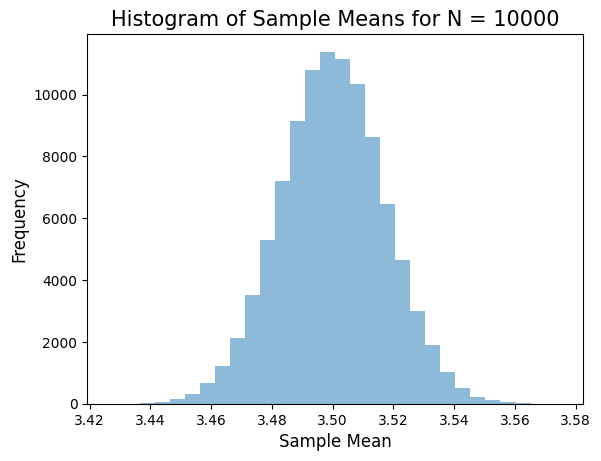

<Figure size 640x480 with 0 Axes>

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

mu = 7/2
sigma = np.sqrt(35/12)

n_rolls = [10, 100, 1000, 10000]
n_expt = 100000

for N in n_rolls:
    clear_output(wait=True)
    sim_mean = np.mean(np.random.randint(1,7,size = (N,n_expt)), axis = 0)
    norm_sim_mean = (sim_mean - mu)/(sigma/np.sqrt(N))
    plt.hist(sim_mean, bins = 30, density = False, alpha = 0.5)
    #plt.xlim(2.5, 4.5)
    plt.title(f'Histogram of Sample Means for N = {N}', size = 15)
    plt.xlabel('Sample Mean', size = 12)
    plt.ylabel('Frequency', size = 12)
    plt.pause(1)
    plt.clf()
#plt.show()
